# Day 08. Exercise 05
# Clustering

## 0. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans # создает кластеры, центр кластера вычисляется как среднее положение всех точек в этом кластере
from sklearn.cluster import DBSCAN # пространственная кластеризация с шумом на основе плотности
from sklearn.cluster import AgglomerativeClustering # иерархический метод кластеризации

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [2]:
df = pd.read_csv('../data/regression.csv', sep=',')
df.drop(columns=['pageviews'], inplace = True)
df.head()

,uid,num_commits,AVG(diff)
0,user_1,62,-64.400000
1,user_10,20,-74.800000
2,user_14,61,-159.000000
3,user_17,51,-61.600000
4,user_18,5,-5.666667


## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [3]:
X = df[['num_commits', 'AVG(diff)']].values

In [4]:
model = KMeans(random_state=21, n_clusters=3)
model.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,21
,copy_x,True
,algorithm,'lloyd'


In [5]:
pred = model.predict(X)

In [6]:
model.labels_

array([0, 0, 1, 0, 0, 2, 2, 2, 2, 1, 1, 0, 2, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 2, 1, 0, 1, 1], dtype=int32)

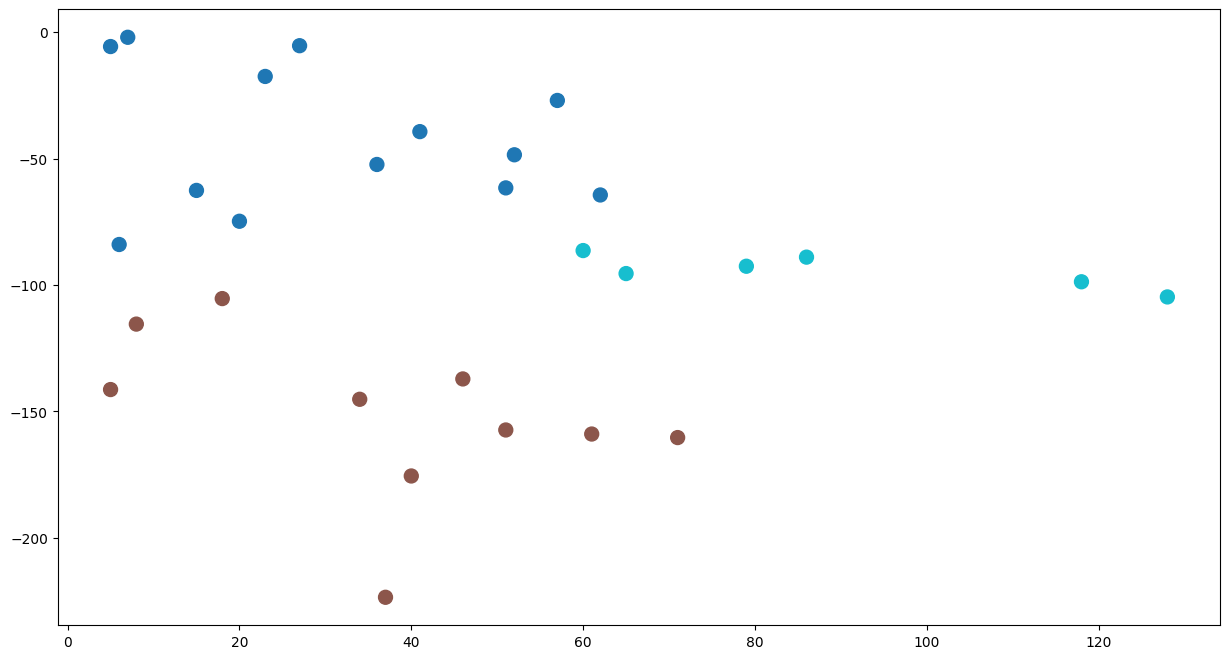

In [7]:
plt.figure(figsize=(15,8))
plt.scatter(X[:,0], X[:,1], c=model.labels_, s=100, cmap='tab10')

In [8]:
silhouette_score(X, pred)

0.4454402135233297

## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [9]:
clustering = DBSCAN(eps=20, min_samples=2)
clusterings = clustering.fit_predict(X)

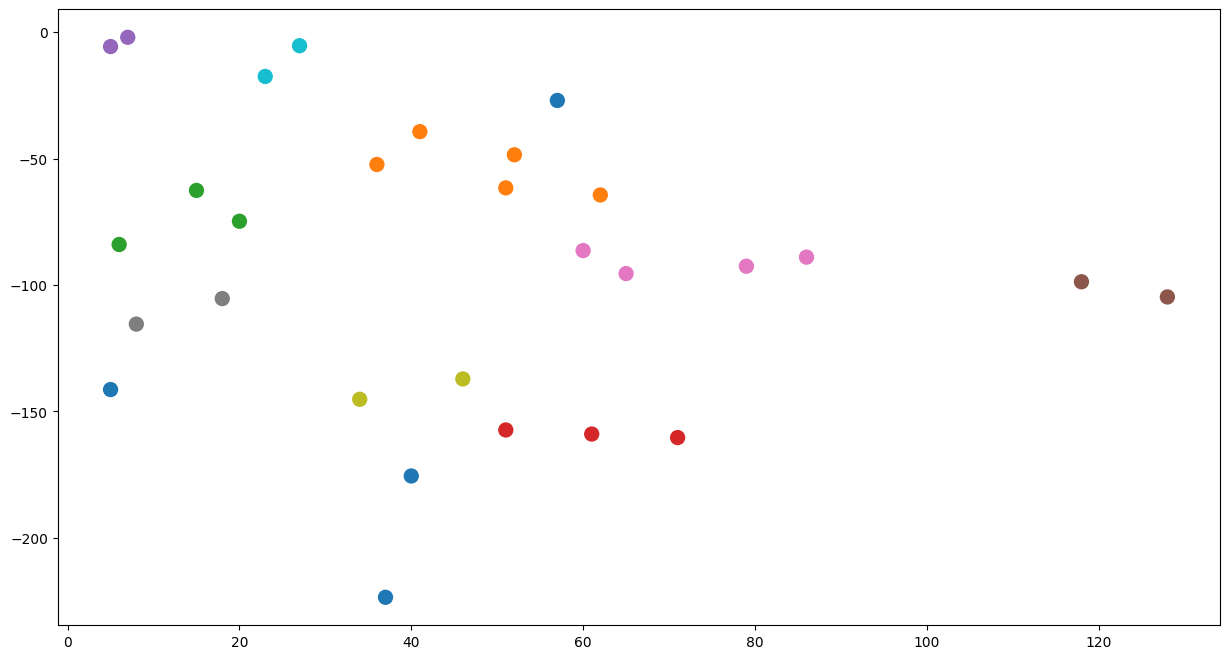

In [10]:
plt.figure(figsize=(15, 8))
plt.scatter(X[:,0], X[:,1], c=clustering.labels_, s=100, cmap='tab10')
plt.show()

In [11]:
silhouette_score(X, clusterings)

0.38339641455696616

## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

In [12]:
clustering = AgglomerativeClustering(n_clusters=5)
clusterings = clustering.fit_predict(X)

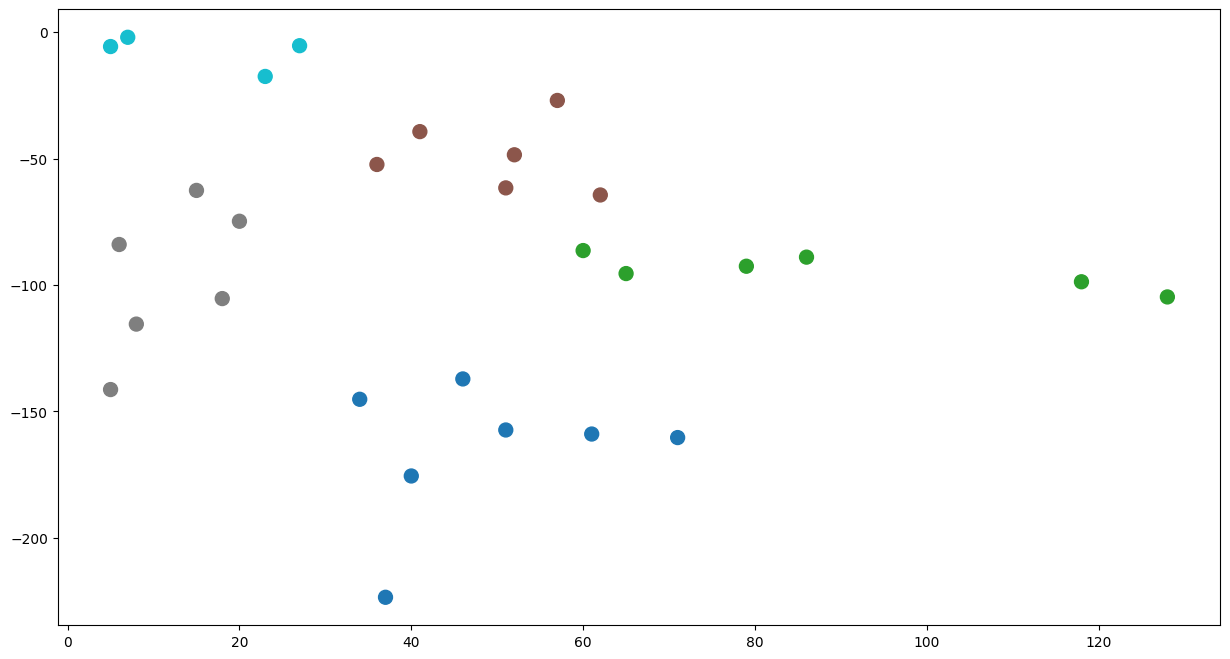

In [13]:
plt.figure(figsize=(15, 8))
plt.scatter(X[:,0], X[:,1], c=clustering.labels_, s=100, cmap='tab10')
plt.show()

In [14]:
silhouette_score(X, clusterings)

0.46383015199381467

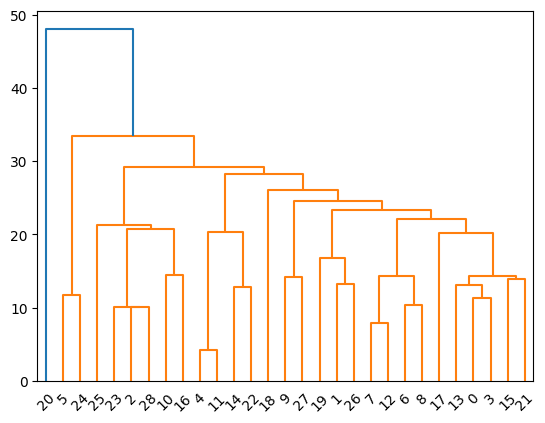

<Figure size 1500x800 with 0 Axes>

In [15]:
Z = hierarchy.linkage(X)
hierarchy.dendrogram(Z)
plt.figure(figsize=(15, 8))
plt.show()

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

In [21]:
def plot_clustering(model, params, optimization_parameter, range_parameter, X):
    scores = []
    for value in range_parameter:
        parameters = params.copy()
        parameters[optimization_parameter] = value
        cluster = model(**parameters)
        clustering = cluster.fit_predict(X)
        scores.append((silhouette_score(X, clustering), int(value)))
    
#    print(*scores)
    best_score, best_value = max(scores, key=lambda x: x[0])
#    print(best_score, best_value)
    print(f'The best parameter of {optimization_parameter} for {model.__name__} is {best_value}')

    parameters = params.copy()
    parameters[optimization_parameter] = best_value
    cluster = model(**parameters)
    clustering = cluster.fit_predict(X)
    
    fig, (plot1, plot2) = plt.subplots(1, 2, figsize=(15, 8))
    
    score, param = zip(*scores)
#    print(score)
#    print(param)
    plot1.plot(param, score, marker='o')
    plot2.scatter(X[:,0], X[:,1], c=cluster.labels_, s=50, cmap='tab10')
    
    plt.show()

The best parameter of n_clusters for KMeans is 8


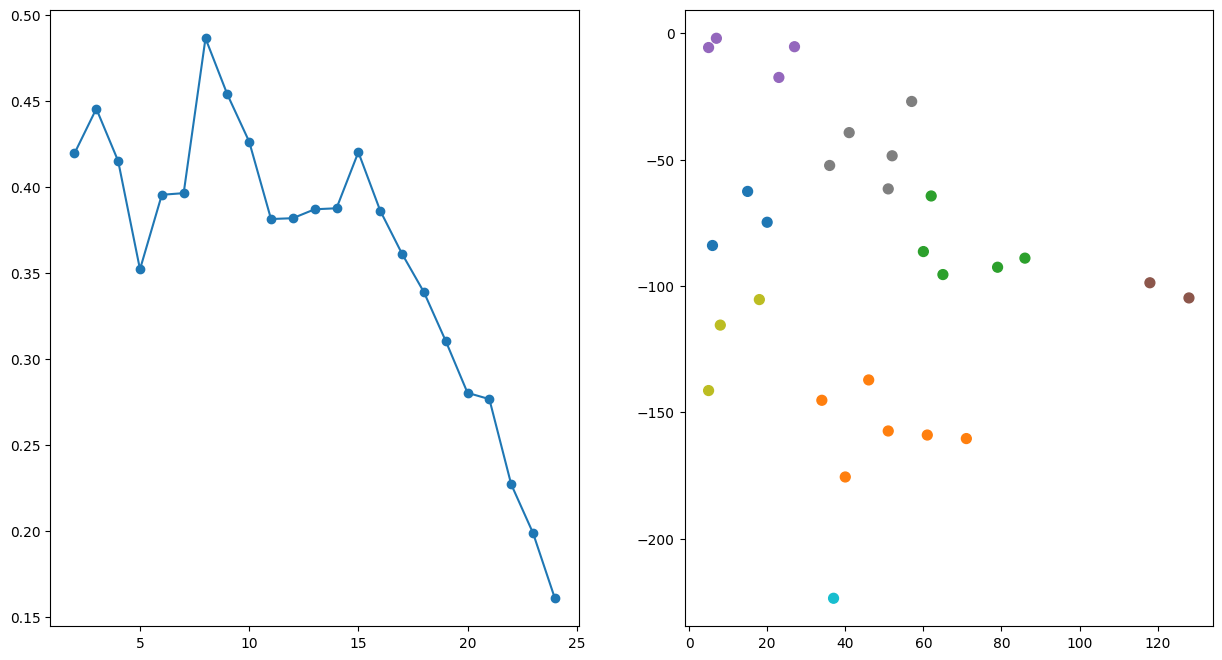

In [22]:
plot_clustering(KMeans, {'random_state':21}, 'n_clusters', range(2,25), X)

The best parameter of eps for DBSCAN is 22


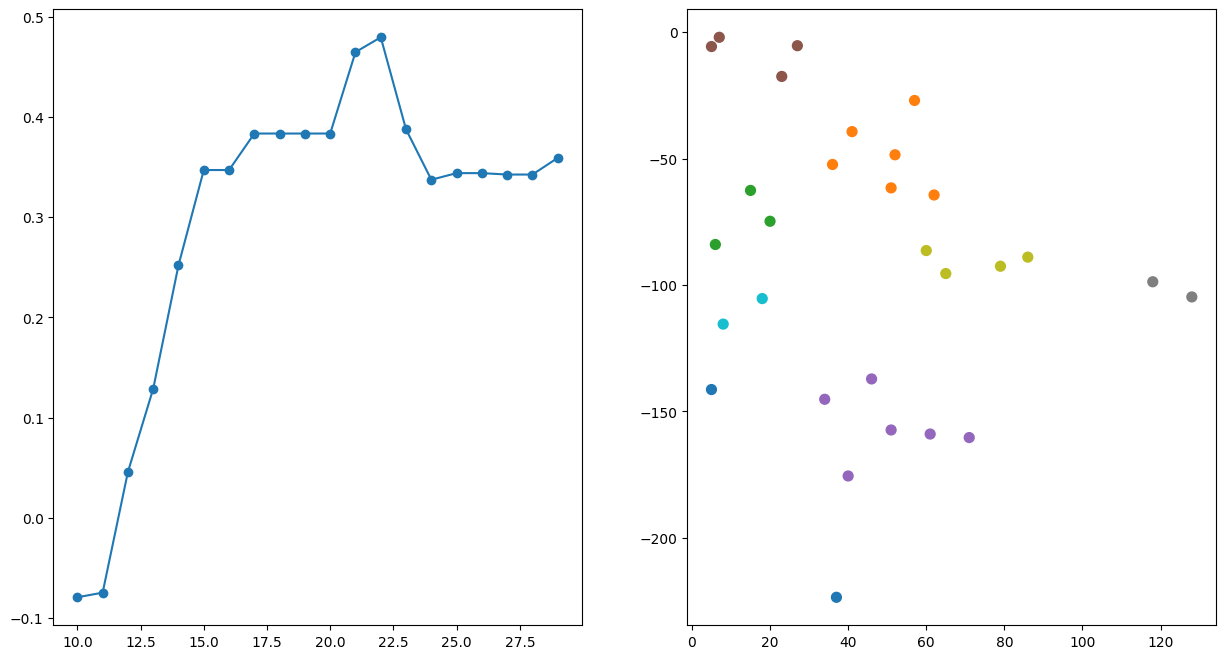

In [23]:
plot_clustering(DBSCAN,
                {'min_samples':2},
                'eps',
                range(10, 30),
                X)

The best parameter of min_samples for DBSCAN is 1


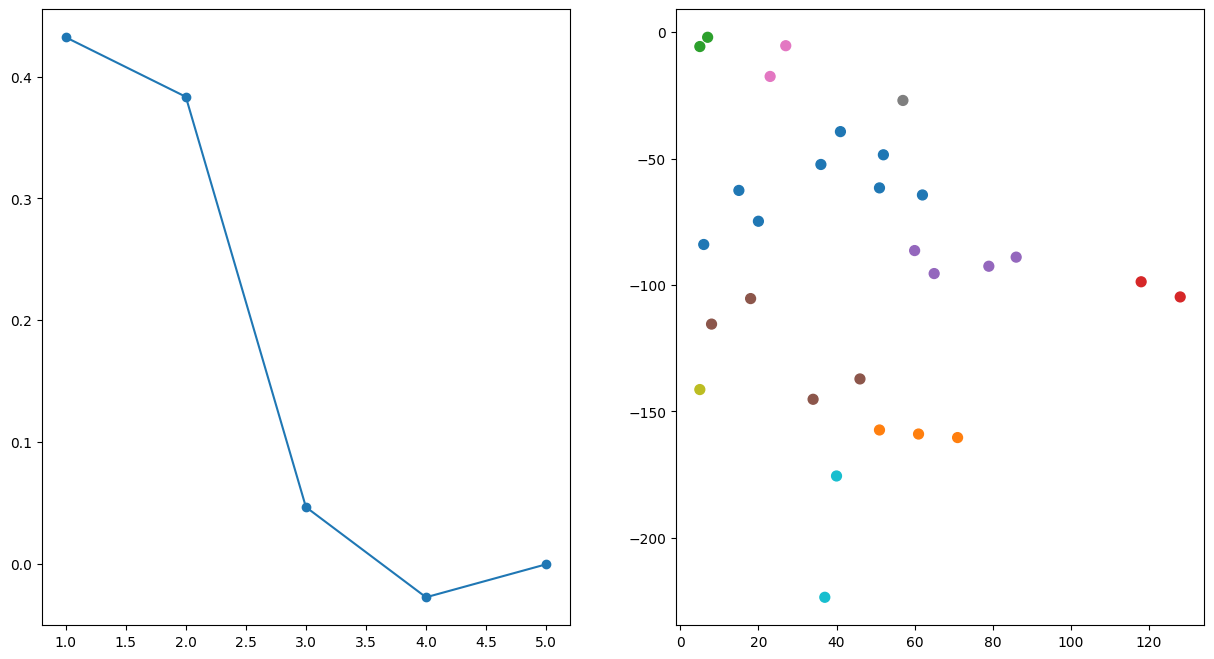

In [24]:
plot_clustering(DBSCAN,
                {'eps':20},
                'min_samples',
                range(1, 6),
                X)

The best parameter of n_clusters for AgglomerativeClustering is 8


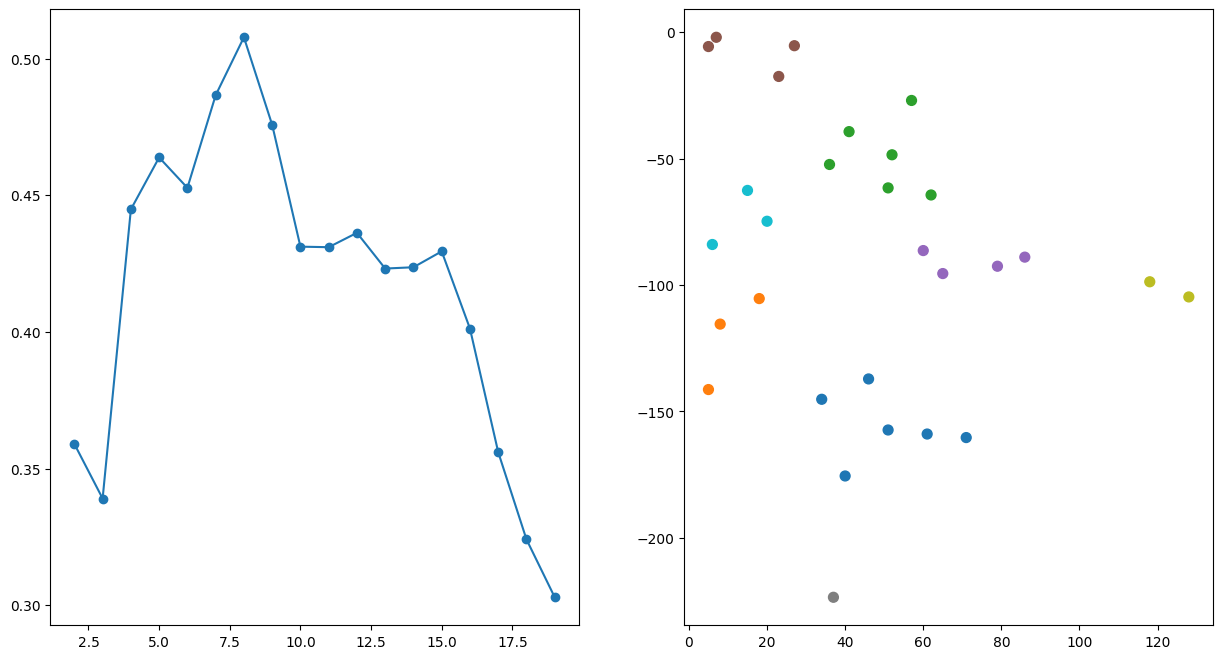

In [25]:
plot_clustering(AgglomerativeClustering,
                {},
                'n_clusters',
                range(2, 20),
                X)